# IRIS ANN
## Muhammad Nadzhif Fikri
## 2306210102

## Introduction
ANN or Artificial Neural Network mimics how brains process informations and make decisions. It utilizes artifical neurons that takes in inputs and fire out outputs to other interconnected neurons that leads to the final decision outputs.

The dataset used for this ANN is The Iris Dataset which can be accessed from scikit via the `sklearn` library. It contains a 150x4 numpy array which each column corresponds to different measures (Sepal Length, Sepal Width, Petal Length, Petal Width) for different iris flower species (Setosa, Versicolour, Viriginica).

## Network Architecture
This ANN consists of inputs which are represented by 4 attributes and 3 possible outputs which are one-hot encoded from the original iris dataset.

Inputs are then passed into the hidden layers of size (`HNODE_COUNT` X `HLAYER_COUNT`) which would then pass data into the output nodes (3 nodes). To do this, several weight matrices are used:
- One with size (`HNODE_COUNT` X `INODE_COUNT`) which would transform data from the input nodes into the first hidden layer nodes.
- `HLAYER_COUNT` matrices of size (`HNODE_COUNT` X `HNODE_COUNT`) to transform data in between hidden layers and
- One matrix of size (`HNODE_COUNT` X `ONODE_COUNT`) which finally transforms the last of the hidden layers to the output layers.

Following this, there is also a matrix of biases with each value corresponding to each node used.

Each node also has activation functions. Hidden layer nodes are activated with ReLU while the output layer is activated with Softmax to be distributed evenly.

Each one-hot encoded output are then evaluated with Cross-Entropy Loss for multiclass classification since there are 3 different classes (non-binary). This loss value is used as a reevaluation value for backpropagation.



## Implementation

### Importing Libraries

In [330]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt


### Dataset Preprocessing

The data from `load_iris()` are first adjusted. The input attributes are first standardize by adjusting to each of their mean and scaling by their standard deviation. This is chosen over linear normalization since it can reduce outliers over normally distributed measurements in different flowers (generally they have similar measurements). In code, it is done by the `standardize()` function.

Data is then required to be split between training and testing data. To ensure that there won't be input output mismatch, inputs and outputs are first merged into one larger numpy array. Numpy `shuffle()` is then used to reorder the data randomly. Data is then split by finding a split index which is then used for Python list slicing.

In [331]:
np.random.seed(67) # Consistency between runs

iris = load_iris()
dataset = np.zeros((iris.data.shape[0], iris.data.shape[1] + 1))

inputs, outputs = iris.data, iris.target

def standardize(inputs):
    inputs = inputs.T
    for attribute in inputs:
        mean = np.mean(attribute)
        std = np.std(attribute)
        attribute -= mean
        attribute /= std
    return inputs.T

inputs = standardize(inputs)

dataset[:, :-1], dataset[:, -1] = inputs, outputs

np.random.shuffle(dataset)

SPLIT_PERCENT = 0.8
train_count = int(dataset.shape[0] * SPLIT_PERCENT)
test_count = int(dataset.shape[0] - train_count)

data_train = dataset[:train_count]
data_test = dataset[train_count:]


To evaluate the dataset output in response the the number of the neural network's output nodes, the dataset outputs are first one hot encoded with `one_hot()` which generates one hot encoded values by utilizing different rows of a normal matrix from `numpy.eye()`.

In [332]:
def one_hot(y):
    y = y.reshape(-1).astype(int)
    class_count = np.max(y) + 1
    return np.eye(class_count)[y]

x_train, y_train = data_train[:, :-1].T, one_hot(data_train[:, -1])
x_test, y_test = data_test[:, :-1].T, data_test[:, -1]

### Important Functions

### ReLU
ReLU is used as an activation function in between layers. The derivative of ReLU is also created as a function (basically a heaviside function since its d/dx = 1 when x > 0).

### Softmax
Softmax is used to evenly distribute the output nodes. Each value is first substracted by the greatest value to prevent overflow. Finally, each value is adjusted to exponent / sum of exponents.

### Cross Entropy loss
Each prediction values are first clipped to values between 1^-13 - 1.0 to prevent 0 values which would produce infinity at log(0). The CE loss is then calculated to be the mean of -y_true * log(y_pred).

In [333]:
def ReLU(Z):
    return np.maximum(0, Z)

def dReLU(Z):
    return (Z > 0).astype(float)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def CE_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-12, 1.0)
    return -np.mean(y_true * np.log(y_pred), axis=0)

### ANN Class

#### Initialization
The class needs to store the number of nodes of the neural network. The number of nodes is adjuted in accordance to its input node count, its output node count, and its hidden layer dimension.

With those spesifications, weights and biases for each nodes are initialized to random values.

#### Forward Propagation
Forward propagation calculation is done on 3 steps. The first step transforms the input to the hidden layers. It is followed with a number of calculations for each of the hidden layers. Finally, the output result is calculated from the last hidden layers.

Each layer uses the ReLU activation function except the last output layer which uses softmax.

The results of each layers (Calculated Z and Activated A) are stored in different lists to be used in the next backward propagation.

#### Backward Propagation
Backward propagation is done in reverse from the output to the hidden layers to the inputs.

Back propagating the hidden layer from output uses a formula derived from chain rule of the derivation of loss, softmax, and weights as referenced [here](https://alexcpn.medium.com/yet-another-backpropagation-article-20ae57aabd1e).

Each hidden layers propagate backwards with derivatives of the ReLU and weights and biases itself (dReLU() * a[i - 1]).

Each weight are then adjusted by substracting each propagation scaled by a learning rate.

#### Training
Training uses a loop that goes back and forth between forward and backward propagation an epoch number of times. Each cycle also evaluates loss which is then stored in an array to returned. Loss in every 10% epoch is also printed as progress.

In [334]:
class ANN:
    def __init__(self, input_size: int, output_size: int, hl_dimension: tuple[int, int]):
        self.input_size = input_size
        self.output_size = output_size
        self.hl_dimension = hl_dimension

        self.winput = np.random.rand(hl_dimension[0], input_size) - 0.5
        self.binput = np.random.rand(hl_dimension[0], 1) - 0.5

        self.w = np.random.rand(hl_dimension[1], hl_dimension[0], hl_dimension[0]) - 0.5
        self.b = np.random.rand(hl_dimension[1], hl_dimension[0], 1)

        self.woutput = np.random.rand(output_size, hl_dimension[0]) - 0.5
        self.boutput = np.random.rand(output_size, 1) - 0.5

    def forward(self, x: np.ndarray):
        self.Z = []
        self.A = []

        A = x
        self.A.append(A)  # input layer

        # Input to hidden
        Z = np.dot(self.winput, A) + self.binput
        A = ReLU(Z)
        self.Z.append(Z)
        self.A.append(A)

        # Hidden layers
        for i in range(self.hl_dimension[1]):
            Z = np.dot(self.w[i], A) + self.b[i]
            A = ReLU(Z)
            self.Z.append(Z)
            self.A.append(A)

        # Hidden to output
        Z = np.dot(self.woutput, A) + self.boutput
        A = softmax(Z)
        self.Z.append(Z)
        self.A.append(A)

        return A

    def backward(self, x, y_true, rate=0.01):
        m = x.shape[1]

        Y = y_true.T

        dZ = self.A[-1] - Y

        dW_out = (1/m) * np.dot(dZ, self.A[-2].T)
        db_out = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        dA = np.dot(self.woutput.T, dZ)

        for i in reversed(range(len(self.w))):
            dZ = dA * dReLU(self.Z[i+1])

            dW = (1/m) * np.dot(dZ, self.A[i+1].T)
            db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            dA = np.dot(self.w[i].T, dZ)

            self.w[i] -= rate * dW
            self.b[i] -= rate * db

        dZ = dA * dReLU(self.Z[0])
        dW_in = (1/m) * np.dot(dZ, self.A[0].T)
        db_in = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        self.winput -= rate * dW_in
        self.binput -= rate * db_in

        self.woutput -= rate * dW_out
        self.boutput -= rate * db_out


    def train(self, X, y, epochs=1000, rate=0.03):
        losses = []
        for i in range(epochs):
            y_pred = self.forward(X)
            loss = CE_loss(y.T, y_pred)

            losses.append(float(np.mean(loss)))

            self.backward(X, y, rate)

            if i % int(epochs / 10) == 0:
                print(f"Epoch {i}, Loss: {np.mean(loss)}")

        return losses

    def test(self, X, y):
        y_pred = self.forward(X)
        loss = CE_loss(y.T, y_pred)
        return np.mean(loss)

### Training
The model is trained with several hyperparameters
- `EPOCHS`
- `HIDDEN_LAYERS` (Dimension in node x layers)
- `LEARNING_RATE`

Training loss data per epoch is then used with `matplotlib` to create a plot of loss  for each epoch.

Epoch 0, Loss: 0.3858085814019078
Epoch 50, Loss: 0.370063985291656
Epoch 100, Loss: 0.364050662346532
Epoch 150, Loss: 0.3599129430224998
Epoch 200, Loss: 0.3558755523380477
Epoch 250, Loss: 0.35096387208619373
Epoch 300, Loss: 0.3442719397123323
Epoch 350, Loss: 0.33480379158879087
Epoch 400, Loss: 0.3215562948737304
Epoch 450, Loss: 0.3034482048440129


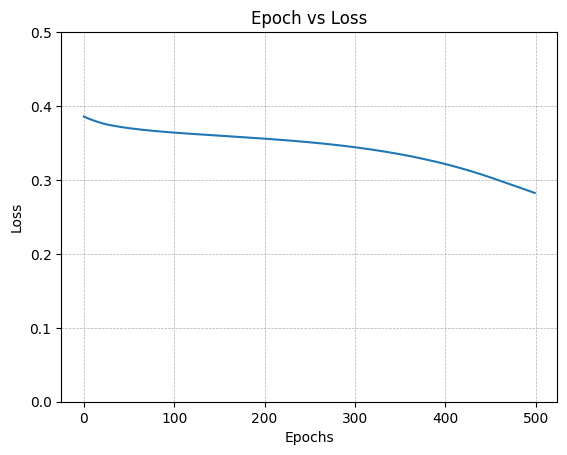

In [335]:
EPOCHS = 500
LEARNING_RATE = 0.01
HIDDEN_LAYERS = (3, 2)

iris_ann = ANN(4, 3, HIDDEN_LAYERS)

losses = []
losses = iris_ann.train(x_train, y_train, EPOCHS, LEARNING_RATE)

def plot_loss(losses, title="Epoch vs Loss"):
    plt.title(title)
    plt.ylim((0, 0.5))
    plt.plot(range(len(losses)), losses)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(linestyle = '--', linewidth = 0.5)
    plt.show()

plot_loss(losses)

## Evaluation

By comparing the outputs and predicted outputs, `evaluate_accuracy()` gives the percentage of accurate predictions. It can also print the failed predictions with their losses. In this case, a model with 500 epochs, 0.01 learning rate, and 3x2 hidden layers produces 63.33% accuracy with 11 failed test guesses.

In [336]:
def evaluate_accuracy(x, y, model: ANN, verbose=False):
    count = len(y)
    pred_test = model.forward(x).T
    loss = CE_loss(one_hot(y).T, pred_test.T)
    species = ["Setosa", "Versicolour", "Viriginica"]
    correct_count = 0
    if verbose:
        print(" Failed Predictions ".center(80, '='))
    for i in range(count):
        pred_value = np.argmax(pred_test[i])
        if pred_value == y[i]:
            correct_count += 1
        elif verbose:
            print(f"{i+1:4d}.| Pred: {species[pred_value]:10s} \t| Ans: {species[int(y_test[i])]:10s} \t| Loss: {loss[i]:.4f}")
    accuracy = correct_count / count * 100
    if verbose:
        print(f"Accuracy: {accuracy:.2f}%")
    return correct_count / test_count * 100

evaluate_accuracy(x_test, y_test, iris_ann, verbose=True)

============================== Failed Predictions ==============================
   2.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3375
   3.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3438
   6.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3545
   7.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3703
   8.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3339
  11.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3442
  12.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3342
  17.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3508
  20.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3435
  22.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3445
  27.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3541
Accuracy: 63.33%


63.33333333333333

### Evaluating Multiple Hyperparameters

To evaluate for different hyperparameter, training and is redone for different parameters
- Larger/Smaller Epochs
- Larger/Smaller Hidden Layers
- Larger/Smaller Learning rate
Random seed is redone in between to ensure consistency.

### Larger Epochs

Epoch 0, Loss: 0.3592164133329355
Epoch 100, Loss: 0.3530672956902366
Epoch 200, Loss: 0.3444424067244865
Epoch 300, Loss: 0.33197650712375926
Epoch 400, Loss: 0.3148871995354782
Epoch 500, Loss: 0.28998238352352057
Epoch 600, Loss: 0.25608424026946713
Epoch 700, Loss: 0.21861306132925037
Epoch 800, Loss: 0.1860835668700887
Epoch 900, Loss: 0.16031742251654535


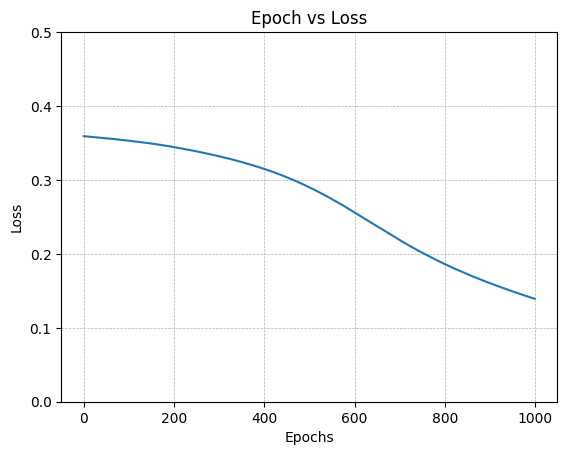

============================== Failed Predictions ==============================
   4.| Pred: Setosa     	| Ans: Versicolour 	| Loss: 0.2835
  29.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.2753
Accuracy: 93.33%


93.33333333333333

In [324]:
np.random.seed(67)
iris_large_epochs = ANN(4, 3, HIDDEN_LAYERS)
losses = iris_large_epochs.train(x_train, y_train, 1000, LEARNING_RATE)
plot_loss(losses)
evaluate_accuracy(x_test, y_test, iris_large_epochs, verbose=True)

### Smaller Epochs

Epoch 0, Loss: 0.3592164133329355
Epoch 25, Loss: 0.3578153172920017
Epoch 50, Loss: 0.3563804940886786
Epoch 75, Loss: 0.3547954095427591
Epoch 100, Loss: 0.3530672956902366
Epoch 125, Loss: 0.3512320695431577
Epoch 150, Loss: 0.3492521725458256
Epoch 175, Loss: 0.3469970506804955
Epoch 200, Loss: 0.3444424067244865
Epoch 225, Loss: 0.34165498555851836


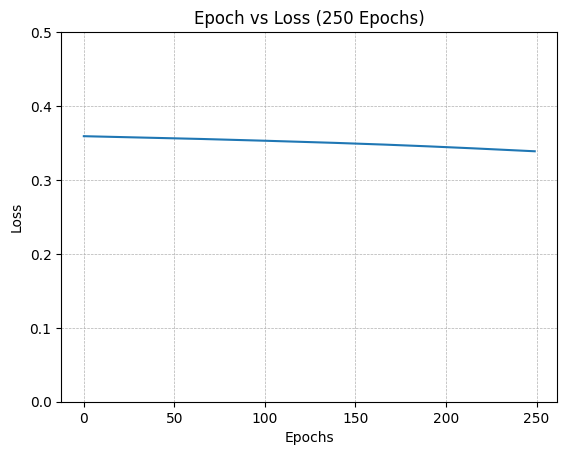

============================== Failed Predictions ==============================
   2.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3386
   3.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3397
   4.| Pred: Setosa     	| Ans: Versicolour 	| Loss: 0.3507
   7.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3870
   8.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3323
  11.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3505
  12.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3340
  17.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3701
  20.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3360
  22.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3483
  27.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3586
Accuracy: 63.33%


63.33333333333333

In [325]:
np.random.seed(67)
iris_small_epochs = ANN(4, 3, HIDDEN_LAYERS)

# Train for 250 epochs
small_losses = iris_small_epochs.train(x_train, y_train, 250, LEARNING_RATE)

# Plot the training loss
plot_loss(small_losses, title="Epoch vs Loss (250 Epochs)")

# Evaluate accuracy on the test set
evaluate_accuracy(x_test, y_test, iris_small_epochs, verbose=True)

### Larger Hidden Layers


Epoch 0, Loss: 0.36612443647752424
Epoch 50, Loss: 0.3608828250411287
Epoch 100, Loss: 0.3569305105014847
Epoch 150, Loss: 0.35268237212959
Epoch 200, Loss: 0.34722631473540466
Epoch 250, Loss: 0.33972260942151944
Epoch 300, Loss: 0.3284376257039662
Epoch 350, Loss: 0.31098071391344323
Epoch 400, Loss: 0.28556386681286194
Epoch 450, Loss: 0.26157947253708336


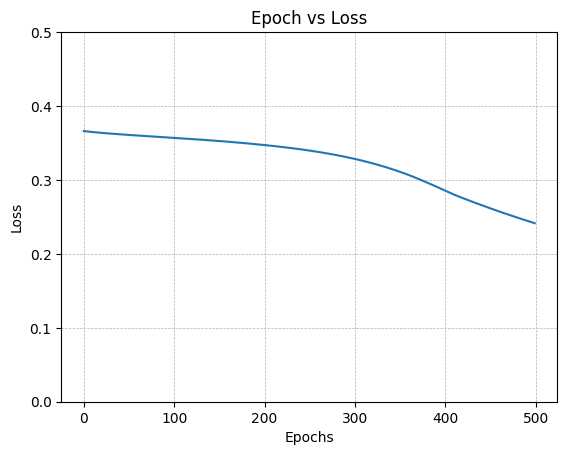

============================== Failed Predictions ==============================
   2.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.2645
  11.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.2865
  12.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3006
  20.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.2661
Accuracy: 86.67%


86.66666666666667

In [326]:
np.random.seed(67)
iris_large_layers = ANN(4, 3, (6,4))
losses = iris_large_layers.train(x_train, y_train, EPOCHS, LEARNING_RATE)
plot_loss(losses)
evaluate_accuracy(x_test, y_test, iris_large_layers, verbose=True)

### Smaller Hidden Layers

Epoch 0, Loss: 0.3641599746797232
Epoch 50, Loss: 0.35942013211404344
Epoch 100, Loss: 0.35392416140385663
Epoch 150, Loss: 0.3484744193211438
Epoch 200, Loss: 0.3425483436115019
Epoch 250, Loss: 0.3355917683642303
Epoch 300, Loss: 0.3273757722005149
Epoch 350, Loss: 0.316981628662967
Epoch 400, Loss: 0.3037560491360574
Epoch 450, Loss: 0.28750853510786506


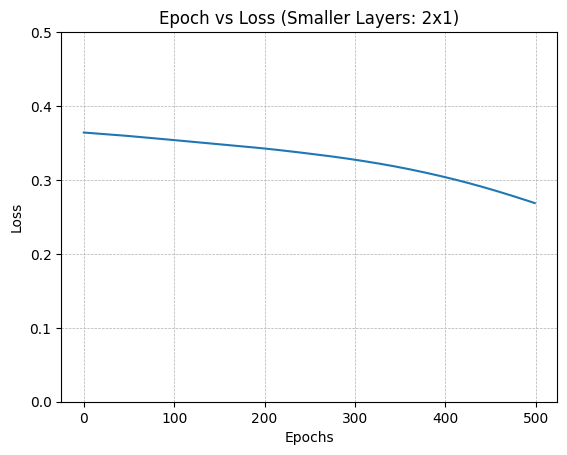

============================== Failed Predictions ==============================
   4.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3260
   5.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3249
  18.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3249
  19.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3251
  26.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3249
  29.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3252
  30.| Pred: Viriginica 	| Ans: Versicolour 	| Loss: 0.3250
Accuracy: 76.67%


76.66666666666667

In [327]:
np.random.seed(67)

iris_small_layers = ANN(4, 3, (2, 1))
small_layer_losses = iris_small_layers.train(x_train, y_train, EPOCHS, LEARNING_RATE)

plot_loss(small_layer_losses, title="Epoch vs Loss (Smaller Layers: 2x1)")

evaluate_accuracy(x_test, y_test, iris_small_layers, verbose=True)

### Larger Learning Rate

Epoch 0, Loss: 0.3592164133329355
Epoch 50, Loss: 0.29187582910944737
Epoch 100, Loss: 0.1404916900757624
Epoch 150, Loss: 0.06367150278370556
Epoch 200, Loss: 0.034635068056304626
Epoch 250, Loss: 0.025825239555456472
Epoch 300, Loss: 0.02194415803694513
Epoch 350, Loss: 0.019815486023648247
Epoch 400, Loss: 0.018490309787413273
Epoch 450, Loss: 0.017594113617996267


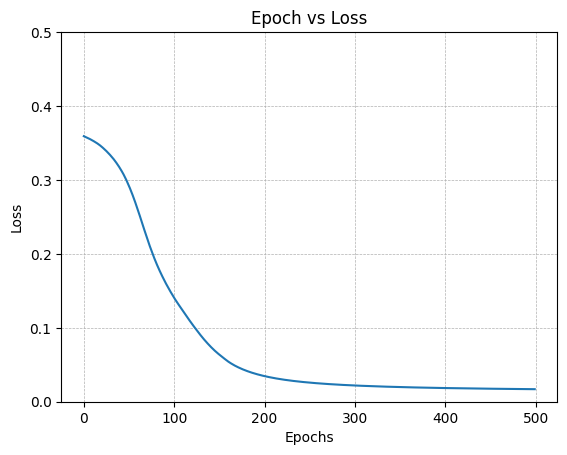

============================== Failed Predictions ==============================
Accuracy: 100.00%


100.0

In [328]:
np.random.seed(67)
iris_large_rate = ANN(4, 3, HIDDEN_LAYERS)
losses = iris_large_rate.train(x_train, y_train, EPOCHS, 0.1)
plot_loss(losses)
evaluate_accuracy(x_test, y_test, iris_large_rate, verbose=True)

### Smaller Learning Rate

Epoch 0, Loss: 0.3592164133329355
Epoch 50, Loss: 0.3589375562528405
Epoch 100, Loss: 0.3586571183963746
Epoch 150, Loss: 0.3583776950403303
Epoch 200, Loss: 0.358096471275373
Epoch 250, Loss: 0.3578147412203718
Epoch 300, Loss: 0.3575350036378978
Epoch 350, Loss: 0.35725795503649244
Epoch 400, Loss: 0.3569713412111204
Epoch 450, Loss: 0.35667818272151036


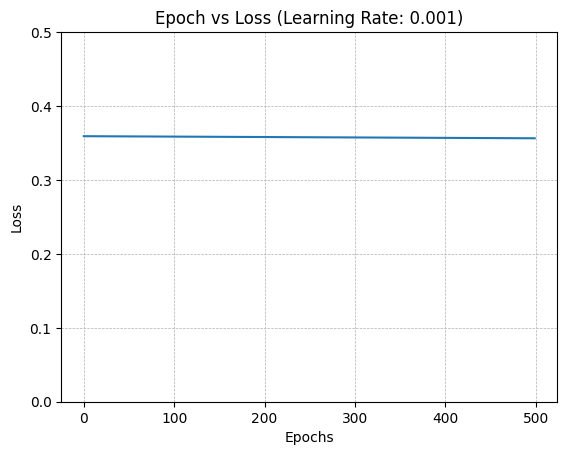

============================== Failed Predictions ==============================
   1.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3596
   2.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3594
   3.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3618
   6.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3587
   7.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3844
   8.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3410
   9.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3616
  10.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3596
  11.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3636
  12.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3468
  13.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3649
  14.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3607
  15.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3685
  16.| Pred: Versicolour 	| Ans: Setosa     	| Loss: 0.3726
  17.| Pred: Versicolour 	| Ans: Viriginica 	| Loss: 0.3768
  20.| Pred: Versic

23.333333333333332

In [329]:
np.random.seed(67)

iris_small_rate = ANN(4, 3, HIDDEN_LAYERS)

small_rate_losses = iris_small_rate.train(x_train, y_train, EPOCHS, 0.001)

plot_loss(small_rate_losses, title="Epoch vs Loss (Learning Rate: 0.001)")

evaluate_accuracy(x_test, y_test, iris_small_rate, verbose=True)

### Comparison


| Experiment | Epochs | Learning Rate | Hidden Layers | Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Control** | 500 | 0.01 | (3, 2) | 63.33%
| **Larger Epochs** | 1000 | 0.01 | (3, 2) | 93.33%
| **Smaller Epochs** | 250 | 0.01 | (3, 2) | 63.33%
| **Larger Layers** | 500 | 0.01 | (6, 4) | 86.67%
| **Smaller Layers** | 500 | 0.01 | (2, 1) | 76.67%
| **Larger Rate** | 500 | 0.1 | (3, 2) | 100.00%
| **Smaller Rate** | 500 | 0.001 | (3, 2) | 23.33%

## Analysis

### Diferent Hyperparameters
Baseline control NN contains a medium accuracy ~63% with mediocre loss progression that only moved slightly and stopped at ~0.3.

Compared to baseline, larger epochs has a similar loss progression but yields a smaller loss due to longer training. This results in a larger accuracy at ~93%

As opposed to the larger epochs, smaller epochs results in a similar slow progression yet results in a still high loss which in turn results in ~63% accuracy. This is a similar accuracy to the baseline which shows that the progression itself is not that different. But when observed with the index of the failed predictions, smaller epochs shows different indexes than baseline which shows the two models are essentially different.

Larger hidden layers yields a loss to epoch result not that far off from baseline yet it has a way higher accuracy of ~86%.

Unexpectedly, smaller hidden layers in turn results with an accuracy of ~76% which is higher than baseline. This shows that the architecture of hidden layers itself may result in unexpected results due to its hidden properties compared to other straightforward hyperparameters.

Larger learning rate produces a steeper loss per epoch curve. This fits with the property of learning rate itself which may speed up learning. This results in a convergent loss value at around ~0.01 with a perfect 100% accuracy.

In turn, smaller learning rate produces a learning curve that barely moves. This also results with the worst accuracy of ~23%.

### Challenges Faced
This assignment turned out harder than expected, I struggled in properly utilizing numpy due to my unfamiliarity. Other than that, backwards propagation turned out to be difficult to grasp which I only grasped after doing some visual jotting and derivations on paper. This resulted in a late submission I am sorry 🙏.

## Conclusion
- In the case of IRIS classification, learning rate affects accuracy the most.
- Hiden properties of the hidden layer is more unpredictable than other hyperparameters.

## References
- GeeksforGeeks, “Artificial Neural Networks and its Applications,” GeeksforGeeks, Jun. 24, 2020. https://www.geeksforgeeks.org/deep-learning/artificial-neural-networks-and-its-applications/
- “The Iris Dataset,” scikit-learn, 2024. https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html
- Samson Zhang. Building a neural network FROM SCRATCH (no Tensorflow/Pytorch, just numpy & math). (2020). [Online Video]. Available: https://youtu.be/w8yWXqWQYmU?si=a6MyRDYDOHn3sjFk
- S. Sena, “Pengenalan Deep Learning Part 3 : BackPropagation Algorithm,” Medium, Mar. 19, 2018. https://medium.com/@samuelsena/pengenalan-deep-learning-part-3-backpropagation-algorithm-720be9a5fbb8
- A. Punnen, “Backpropagation Deep Dive,” Medium, Jul. 21, 2022. https://alexcpn.medium.com/yet-another-backpropagation-article-20ae57aabd1e